# 2D CNN over spectrogram

This notebook trains the spectrogram model. Inputs are `spec_db` matrices from `dataset/samples/*.npz`.

In [5]:
from pathlib import Path
import sys

METHOD_DIR = Path.cwd()
if METHOD_DIR.name != "2d_cnn_spectrogram":
    METHOD_DIR = Path("methods/2d_cnn_spectrogram").resolve()
sys.path.insert(0, str(METHOD_DIR))

from train_spectrogram_2d_cnn import INDEX_TO_LABEL, LABEL_TO_INDEX, SpectrogramCNN, find_project_root, train

PROJECT_ROOT = find_project_root()
PROJECT_ROOT
DATASET_DIR = PROJECT_ROOT / "dataset_v2"
DATASET_DIR


WindowsPath('C:/code/vlf/Broadband_data/dataset_v2')

In [6]:
import json
import random
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from train_spectrogram_2d_cnn import SpectrogramCNN, build_loaders, run_epoch, predict_loader

EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 3e-4
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, min(6, torch.get_num_threads())))

metadata = pd.read_csv(DATASET_DIR / "metadata.csv")
metadata = metadata[metadata["label"].isin(LABEL_TO_INDEX)].copy()
metadata["target"] = metadata["label"].map(LABEL_TO_INDEX).astype(int)

display(metadata.groupby(["split", "label"]).size().unstack(fill_value=0))

loaders, frames = build_loaders(metadata, DATASET_DIR, BATCH_SIZE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpectrogramCNN().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss()

best_state = None
best_val_f1 = -1.0
history = []

for epoch in range(1, EPOCHS + 1):
    result_train = run_epoch(model, loaders["train"], criterion, optimizer, device, train=True)
    result_val = run_epoch(model, loaders["val"], criterion, optimizer, device, train=False)

    if len(result_train) == 4:
        train_loss, train_f1, _, _ = result_train
        val_loss, val_f1, _, _ = result_val
        train_acc = None
        val_acc = None
    else:
        train_loss, train_acc, train_f1, _, _ = result_train
        val_loss, val_acc, val_f1, _, _ = result_val

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_f1": val_f1,
    }
    if train_acc is not None:
        row["train_accuracy"] = train_acc
        row["val_accuracy"] = val_acc

    history.append(row)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(f"epoch {epoch:02d}: train_loss={train_loss:.4f} train_f1={train_f1:.4f} val_loss={val_loss:.4f} val_f1={val_f1:.4f}")

model.load_state_dict(best_state)

val_y, val_pred, _ = predict_loader(model, loaders["val"], device)
test_y, test_pred, test_prob = predict_loader(model, loaders["test"], device)

report = {
    "model_kind": "spectrogram_2d_dataset_v2",
    "dataset_dir": str(DATASET_DIR),
    "train_samples": int(len(frames["train"])),
    "val_samples": int(len(frames["val"])),
    "test_samples": int(len(frames["test"])),
    "best_val_f1": float(best_val_f1),
    "history": history,
    "val": {
        "f1": float(f1_score(val_y, val_pred, zero_division=0)),
        "precision": float(precision_score(val_y, val_pred, zero_division=0)),
        "recall": float(recall_score(val_y, val_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(val_y, val_pred).tolist(),
    },
    "test": {
        "f1": float(f1_score(test_y, test_pred, zero_division=0)),
        "precision": float(precision_score(test_y, test_pred, zero_division=0)),
        "recall": float(recall_score(test_y, test_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(test_y, test_pred).tolist(),
    },
}

predictions = frames["test"][["sample_id", "source_file", "segment_start", "segment_end", "label", "png_path", "npz_path"]].copy()
predictions["predicted"] = [INDEX_TO_LABEL[int(value)] for value in test_pred]
predictions["prob_no_burst"] = test_prob[:, 0]
predictions["prob_burst"] = test_prob[:, 1]

models_dir = METHOD_DIR / "models"
reports_dir = METHOD_DIR / "reports"
models_dir.mkdir(exist_ok=True)
reports_dir.mkdir(exist_ok=True)

model_path = models_dir / "spectrogram_2d_dataset_v2.pt"
metrics_path = reports_dir / "spectrogram_2d_dataset_v2_metrics.json"
predictions_path = reports_dir / "spectrogram_2d_dataset_v2_predictions.csv"

torch.save(
    {
        "model_kind": "spectrogram_2d_dataset_v2",
        "model_state_dict": model.state_dict(),
        "label_to_index": LABEL_TO_INDEX,
    },
    model_path,
)
metrics_path.write_text(json.dumps(report, indent=2, ensure_ascii=False), encoding="utf-8")
predictions.to_csv(predictions_path, index=False)

print("VAL")
print(confusion_matrix(val_y, val_pred))
print(classification_report(val_y, val_pred, target_names=["no_burst", "burst"], zero_division=0))

print("TEST")
print(confusion_matrix(test_y, test_pred))
print(classification_report(test_y, test_pred, target_names=["no_burst", "burst"], zero_division=0))

print(f"model: {model_path}")
print(f"metrics: {metrics_path}")
print(f"predictions: {predictions_path}")



label,burst,no_burst
split,,
test,254,319
train,1116,1348
val,256,307


epoch 01: train_loss=0.6700 train_f1=0.3402 val_loss=0.6630 val_f1=0.0458
epoch 02: train_loss=0.6203 train_f1=0.6000 val_loss=0.5960 val_f1=0.7088
epoch 03: train_loss=0.5933 train_f1=0.6375 val_loss=0.5777 val_f1=0.5683
epoch 04: train_loss=0.5748 train_f1=0.6567 val_loss=0.5562 val_f1=0.6142
epoch 05: train_loss=0.5629 train_f1=0.6639 val_loss=0.5863 val_f1=0.3694
epoch 06: train_loss=0.5477 train_f1=0.6776 val_loss=0.5297 val_f1=0.5978
epoch 07: train_loss=0.5330 train_f1=0.6888 val_loss=0.5824 val_f1=0.4565
epoch 08: train_loss=0.5271 train_f1=0.6999 val_loss=0.6325 val_f1=0.2876
epoch 09: train_loss=0.5087 train_f1=0.7198 val_loss=0.5048 val_f1=0.6404
epoch 10: train_loss=0.5151 train_f1=0.7045 val_loss=0.4834 val_f1=0.7890
epoch 11: train_loss=0.4995 train_f1=0.7125 val_loss=0.4600 val_f1=0.7640
epoch 12: train_loss=0.4774 train_f1=0.7436 val_loss=0.5787 val_f1=0.4927
epoch 13: train_loss=0.4749 train_f1=0.7512 val_loss=0.4833 val_f1=0.6277
epoch 14: train_loss=0.4797 train_f1=0

WindowsPath('c:/code/vlf/Broadband_data/methods/2d_cnn_spectrogram/reports/spectrogram_2d_training_curves.png')

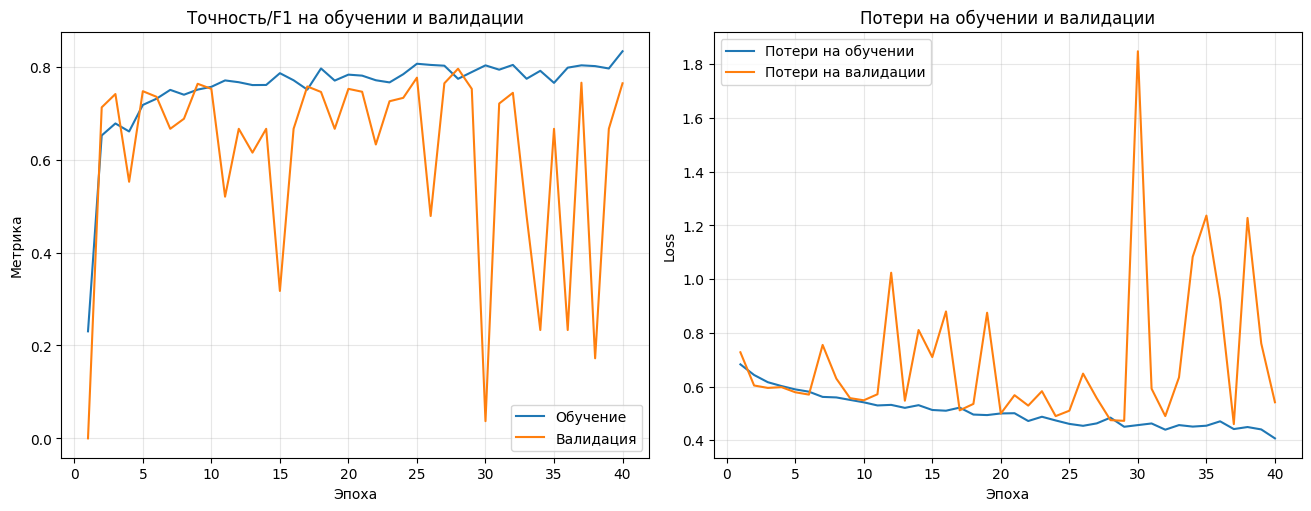

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

history_df = pd.DataFrame(report["history"])

train_metric_col = "train_accuracy" if "train_accuracy" in history_df.columns else "train_f1"
val_metric_col = "val_accuracy" if "val_accuracy" in history_df.columns else "val_f1"

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].plot(history_df["epoch"], history_df[train_metric_col], label="Обучение")
axes[0].plot(history_df["epoch"], history_df[val_metric_col], label="Валидация")
axes[0].set_title("Точность/F1 на обучении и валидации")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Метрика")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_loss"], label="Потери на обучении")
axes[1].plot(history_df["epoch"], history_df["val_loss"], label="Потери на валидации")
axes[1].set_title("Потери на обучении и валидации")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plot_path = METHOD_DIR / "reports" / "spectrogram_2d_training_curves.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(plot_path, dpi=160)

plot_path


WindowsPath('c:/code/vlf/Broadband_data/methods/2d_cnn_spectrogram/reports/spectrogram_2d_val_f1.png')

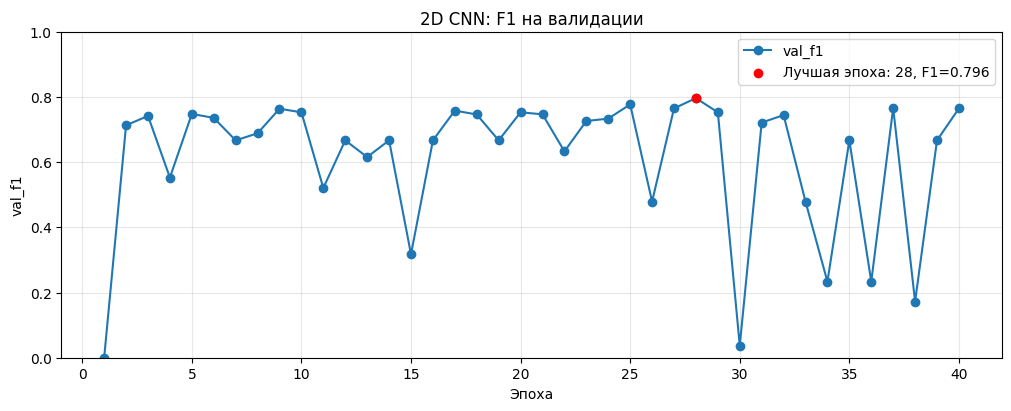

In [4]:
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)

ax.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="val_f1")
best_idx = history_df["val_f1"].idxmax()
best_epoch = int(history_df.loc[best_idx, "epoch"])
best_val_f1 = float(history_df.loc[best_idx, "val_f1"])

ax.scatter([best_epoch], [best_val_f1], color="red", zorder=3, label=f"Лучшая эпоха: {best_epoch}, F1={best_val_f1:.3f}")
ax.set_title("2D CNN: F1 на валидации")
ax.set_xlabel("Эпоха")
ax.set_ylabel("val_f1")
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend()

plot_path = METHOD_DIR / "reports" / "spectrogram_2d_val_f1.png"
fig.savefig(plot_path, dpi=160)

plot_path


## Manual sample check

Set `SAMPLE` to a `sample_id`, `.npz` path, or `.png` path. The model uses `spec_db` from `.npz`; PNG is shown only for visual inspection.

sample_id     : sample_000078
label         : burst
predicted     : no_burst
prob_no_burst : 0.7221
prob_burst    : 0.2779


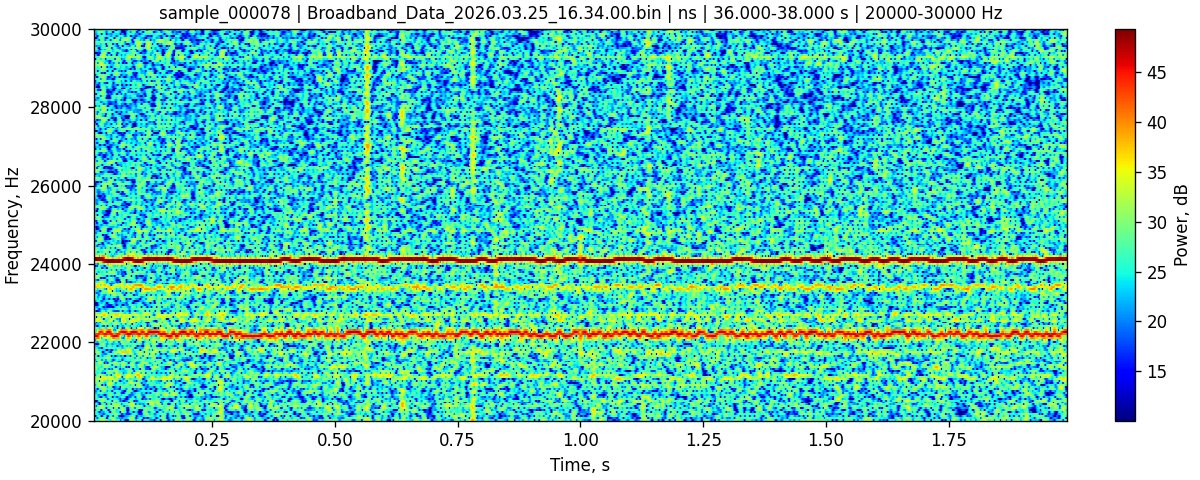

In [4]:
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

metadata = pd.read_csv(PROJECT_ROOT / "dataset" / "metadata.csv")
metadata = metadata[metadata["label"].isin(LABEL_TO_INDEX)].copy()

def row_for_sample(sample: str):
    sample = str(sample).strip().strip('"')
    sample_path = Path(sample.replace("\\", "/"))
    sample_id = sample_path.stem if sample_path.suffix else sample
    rows = metadata[metadata["sample_id"] == sample_id]
    if rows.empty:
        rows = metadata[metadata["npz_path"].astype(str).str.replace("\\", "/", regex=False).str.endswith(sample_path.name)]
    if rows.empty:
        rows = metadata[metadata["png_path"].astype(str).str.replace("\\", "/", regex=False).str.endswith(sample_path.name)]
    if rows.empty:
        raise ValueError(f"Sample not found in metadata: {sample}")
    return rows.iloc[0]

def predict_sample(sample: str, show_image: bool = True):
    row = row_for_sample(sample)
    npz_path = PROJECT_ROOT / "dataset" / Path(str(row["npz_path"]).replace("\\", "/"))
    png_path = PROJECT_ROOT / "dataset" / Path(str(row["png_path"]).replace("\\", "/"))
    data = np.load(npz_path)
    x = data["spec_db"].astype(np.float32)
    x = (x - x.mean()) / (x.std() + 1e-6)
    x = torch.from_numpy(x[None, None, :, :])
    model.eval()
    with torch.no_grad():
        prob = torch.softmax(model(x), dim=1).cpu().numpy()[0]
    predicted = INDEX_TO_LABEL[int(prob.argmax())]
    print(f"sample_id     : {row['sample_id']}")
    print(f"label         : {row['label']}")
    print(f"predicted     : {predicted}")
    print(f"prob_no_burst : {prob[0]:.4f}")
    print(f"prob_burst    : {prob[1]:.4f}")
    if show_image and png_path.exists():
        display(Image(filename=str(png_path)))

SAMPLE = "sample_000078"
predict_sample(SAMPLE)
